In [18]:
import matplotlib.pyplot as plt
import numpy as np
from featuregraph import get_block_coordinates, get_output_cells, get_candidate_transformations

In [19]:
test_input_1 = np.array([
    [8, 3],
    [0, 5],
])

test_input_2 = np.array([
    [2, 7, 4],
    [9, 1, 6],
    [3, 8, 0],
])

test_inputs = [
    test_input_1,
    test_input_2,
]

instruction_layout = np.array([
    [0, 1, 2],
    [2, 0, 1]
])


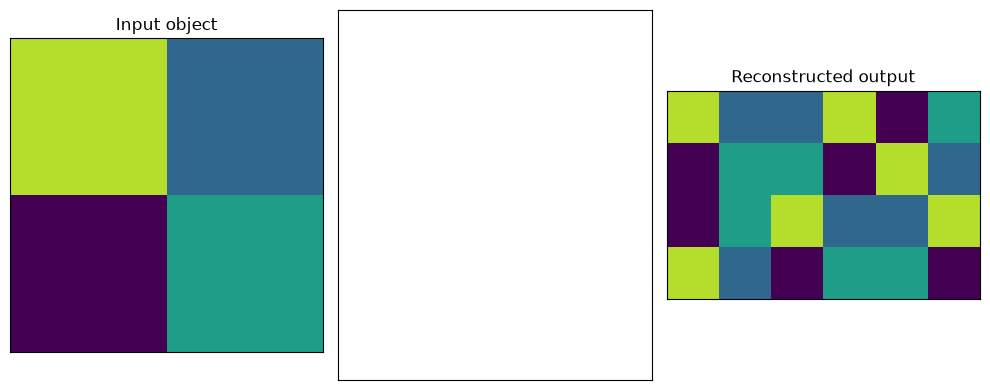

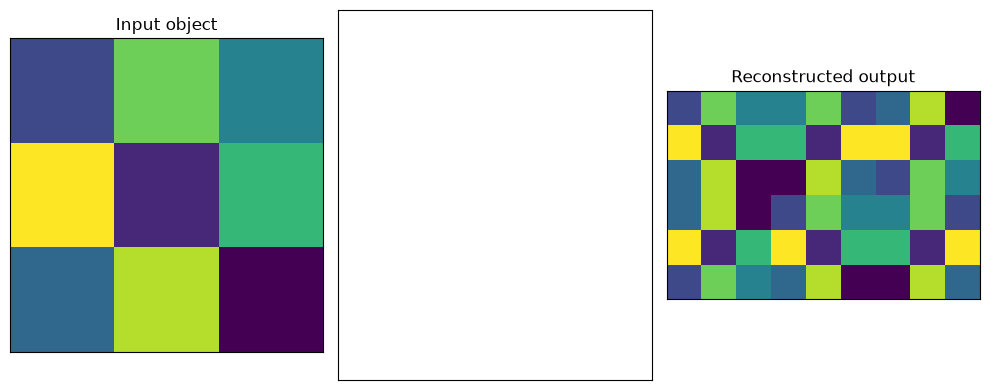

In [ ]:
predictions = []

for input in test_inputs:
    
    input_flip_horizontal = np.fliplr(input)
    input_flip_vertical = np.flipud(input)

    input_height, input_width = input.shape
    predicted_height = instruction_layout.shape[0] * input_height
    predicted_width = instruction_layout.shape[1] * input_width
    predicted_shape = (predicted_height, predicted_width)

    number_of_block_rows = predicted_height // input_height
    number_of_block_columns = predicted_width // input_width

    block_coordinates = get_block_coordinates(input.shape, predicted_shape)
    candidate_transformations = np.array([get_candidate_transformations(v, block_coordinates) for v in [input, input_flip_horizontal, input_flip_vertical]]).T

    cell_indices = np.arange(candidate_transformations.shape[0])
    cell_instructions = instruction_layout[block_coordinates[:,0], block_coordinates[:,1]]
    manual_output = candidate_transformations[cell_indices, cell_instructions].reshape(predicted_shape)

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))

    axes[0].imshow(input, vmin=0, vmax=9)
    axes[0].set_title("Input object")

    axes[2].imshow(manual_output, vmin=0, vmax=9)
    axes[2].set_title("Reconstructed output")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

    predictions.append(manual_output.copy())

In [21]:
expected_test_output_1 = np.array([
    [8, 3, 3, 8, 0, 5],
    [0, 5, 5, 0, 8, 3],
    [0, 5, 8, 3, 3, 8],
    [8, 3, 0, 5, 5, 0],
])

In [22]:
expected_test_output_2 = np.array([
    [2, 7, 4, 4, 7, 2, 3, 8, 0],
    [9, 1, 6, 6, 1, 9, 9, 1, 6],
    [3, 8, 0, 0, 8, 3, 2, 7, 4],
    [3, 8, 0, 2, 7, 4, 4, 7, 2],
    [9, 1, 6, 9, 1, 6, 6, 1, 9],
    [2, 7, 4, 3, 8, 0, 0, 8, 3],
])

In [23]:
np.array_equal(
    predictions[0],
    expected_test_output_1,
)

True

In [24]:
np.array_equal(
    predictions[1],
    expected_test_output_2,
)

True